In [12]:
#%pip install shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score

import shap
sns.set_style('whitegrid')
print('SHAP version:', shap.__version__)

SHAP version: 0.52.0


In [13]:
df = pd.read_csv('../Data/cleaned_data.csv')

X_text = df['cleaned_text'].fillna('')
y = df['fraudulent']

metadata_cols = ['telecommuting','has_company_logo','has_questions','has_company_profile','has_requirements','has_benefits']
X_meta = df[metadata_cols].fillna(0).values

#80/20 split on raw text and metadata
X_text_train, X_text_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text, X_meta, y, test_size=0.2, random_state=42, stratify=y)

#Tf-IDF, same as LR and SVM
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), sublinear_tf=True)
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_test = tfidf.transform(X_text_test)

#Combine text features + metadata
X_train = hstack([X_tfidf_train, csr_matrix(X_meta_train)]).tocsr()
X_test = hstack([X_tfidf_test, csr_matrix(X_meta_test)]).tocsr()

#feature names needed later to label the shap values
features_names = list(tfidf.get_feature_names_out()) + metadata_cols


#LR with class weighting - chosen because job seekers need high recall
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Fraud F1:', round(f1_score(y_test, y_pred)*100, 2))
print('Fraud Recall:', round(recall_score(y_test, y_pred)*100, 2))

Fraud F1: 67.96
Fraud Recall: 91.33


In [14]:
#Linear explainer gives exact shap value for logistic regression

masker = shap.maskers.Independent(X_train, max_samples=1000)
explainer = shap.LinearExplainer(model,masker)

#Compute shap values for the whole test set
shap_values = explainer.shap_values(X_test)

print('SHAP values shape:', shap_values.shape)

Background dataset has 14304 samples but max_samples=1000. Subsampling to 1000 samples for SHAP value computation. To use all samples, set max_samples=14304 when initializing the masker.


SHAP values shape: (3576, 5006)


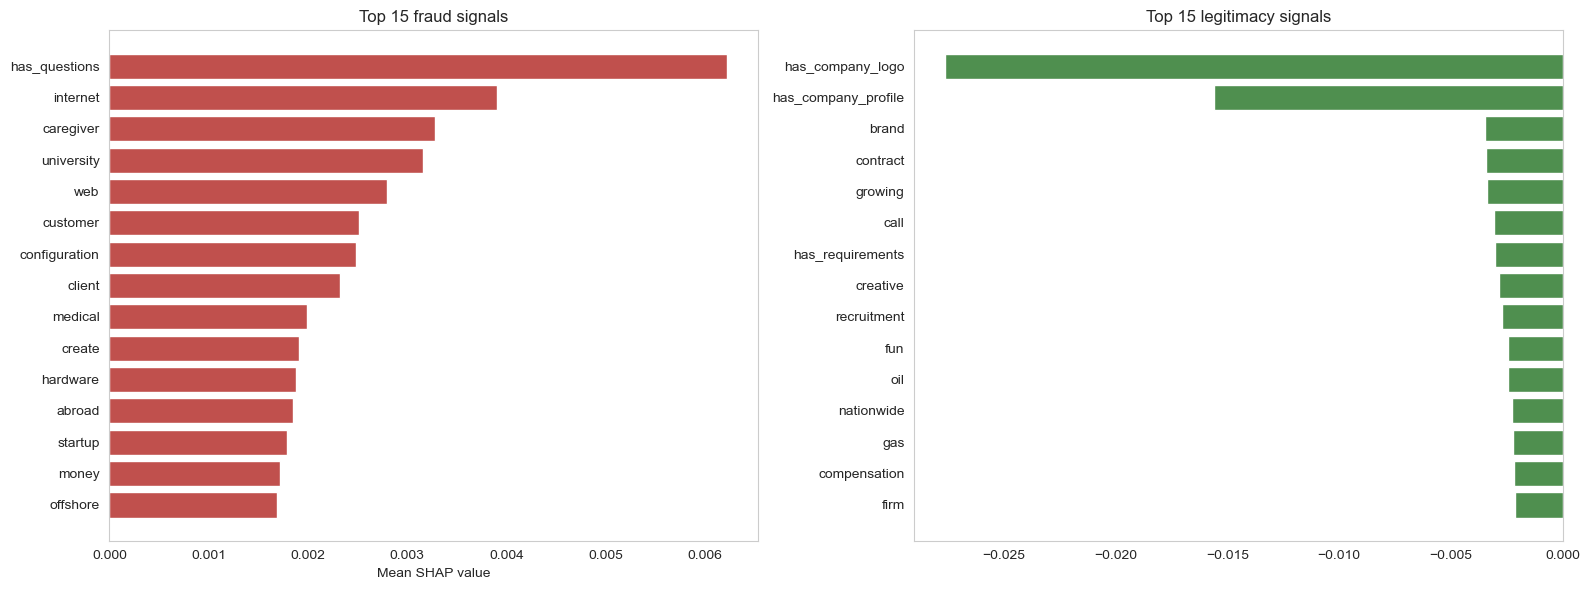

In [5]:
#Average shap value per feature across all test postings
mean_shap = shap_values.mean(axis=0)

shap_summary = pd.DataFrame({
    'feature': features_names,
    'mean_shap': mean_shap
})

top_fraud = shap_summary.nlargest(15, 'mean_shap')
top_real = shap_summary.nsmallest(15, 'mean_shap')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_fraud['feature'][::-1], top_fraud['mean_shap'][::-1], color='#C0504D')
axes[0].set_title('Top 15 fraud signals')
axes[0].set_xlabel('Mean SHAP value')
axes[0].grid(False)

axes[1].barh(top_real['feature'][::-1], top_real['mean_shap'][::-1], color='#4F8F4F')
axes[1].set_title('Top 15 legitimacy signals')
axes[1].grid(False)

plt.tight_layout()
plt.savefig('../Output/shap_global_signals.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
#Find a fraud case from the test set 
y_test_arr = y_test.reset_index(drop=True)
probs = model.predict_proba(X_test)[:, 1]

fraud_idx = [i for i in range(len(y_test_arr)) if y_test_arr[i] == 1 and probs[i] > 0.9]
example = fraud_idx[0]

print(f'Posting #{example} - true label: FRAUD, model score: {probs[example]*100:.1f}%\n')

#Get shap values for this one posting
posting_shap = shap_values[example]
present = X_test[example].toarray().flatten() != 0

contrib = pd.DataFrame({
    'feature': np.array(features_names)[present],
    'shap': posting_shap[present]
}).sort_values('shap', ascending=False)

print('Top reasons flagged as FRAUD:')
print(contrib.head(10).to_string(index=False))
print('\nFeatures pushing toward REAL:')
print(contrib.tail(5).to_string(index=False))

Posting #37 - true label: FRAUD, model score: 90.3%

Top reasons flagged as FRAUD:
            feature     shap
          assistant 0.279481
               wage 0.229479
professional manner 0.145377
        please send 0.144529
           supplier 0.142380
          time full 0.126391
                per 0.122336
      work pressure 0.115302
             proven 0.097439
        requirement 0.096758

Features pushing toward REAL:
      feature      shap
time position -0.072910
       friday -0.087379
       monday -0.092146
     deadline -0.132410
    join team -0.135205


In [7]:
#Build the prototype engine
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

#Same cleaning function as the EDA
def clean_text(text):
    if pd.isna(text) or text is None:
        return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

def explain_posting(raw_text, has_logo=0, has_profile=0, has_reqs=0,
                    has_benefits=0, telecommuting=0, has_questions=0, top_n=8):
    """takes raw job text and returns fraud score plus the words behind it"""
    cleaned = clean_text(raw_text)

    x_tfidf = tfidf.transform([cleaned])
    x_meta = csr_matrix([[telecommuting, has_logo, has_questions,
                          has_profile,has_reqs, has_benefits]])
    x = hstack([x_tfidf, x_meta]).tocsr()

    score = model.predict_proba(x)[0, 1]
    sv = explainer.shap_values(x)[0]
    present = x.toarray().flatten() != 0

    contrib = pd. DataFrame({
        'feature': np.array(features_names)[present],
        'shap': sv[present]
    })

    verdict = 'LIKELY FRAUDULENT' if score >= 0.6 else ('UNCERTAIN' if score >= 0.4 else 'LIKELY LEGITIMATE')
   
    print(f'FRAUD SCORE: {score*100:.1f}% [{verdict}]')
    
    print('\nSigns of fraud:')
    for _, r in contrib.nlargest(top_n, 'shap').iterrows():
        if r['shap'] > 0: print(f"   +{r['feature']} ({r['shap']:.3f})")
    print('\nSigns of legitimacy:')
    for _, r in contrib.nsmallest(top_n, 'shap').iterrows():
        if r['shap'] < 0: print(f"   - {r['feature']} ({r['shap']:.3f})")
    return score

In [16]:
scam = """URGENT hiring! Work from home and earn $500 daily doing simple data entry.
No experience needed. Send your personal bank details to apply now!"""

explain_posting(scam, has_logo=0, has_profile=0, has_reqs=0, has_benefits=0)

FRAUD SCORE: 99.3% [LIKELY FRAUDULENT]

Signs of fraud:
   +earn (1.027)
   +data entry (0.947)
   +work home (0.593)
   +urgent (0.443)
   +entry (0.390)
   +apply (0.278)
   +send (0.256)
   +home (0.251)

Signs of legitimacy:
   - bank (-0.211)
   - experience (-0.071)
   - work (-0.001)


np.float64(0.9927238396439569)

In [17]:
real = """We are seeking an experienced software Engineer to join our team in London.
You will develop backend services using Python and SQL and collaborate with product teams.
Requirements: 3+ years experience, degree in Computer Science
Benefits: competitive salary, pension, private healthcare."""

explain_posting(real, has_logo=1, has_profile=1, has_reqs=1, has_benefits=1);

FRAUD SCORE: 1.5% [LIKELY LEGITIMATE]

Signs of fraud:
   +benefit (0.205)
   +computer (0.136)
   +requirement (0.127)
   +service (0.120)
   +develop (0.102)
   +sql (0.077)
   +has_requirements (0.035)
   +product (0.024)

Signs of legitimacy:
   - join team (-0.302)
   - has_company_profile (-0.289)
   - has_company_logo (-0.248)
   - software engineer (-0.220)
   - python (-0.185)
   - software (-0.181)
   - private (-0.167)
   - healthcare (-0.158)


## Findings

- SHAP confirms the metadata features are doing the heavy lifting - `has_company_logo` and `has_company_profile` are the strongest legitimacy signals overall
- Fraud vocabulary matches the EDA wordclouds: earn, data entry, work home, urgent
- Bigrams matter - "work home" and "data entry" carry more weight than the single words alone, which justifies using ngram_range=(1,2)
- Example posting scored 99.3% fraud with clear reasons, so the output is understandable for a non-technical user
- Some words behave unexpectedly (e.g. "bank" as a legitimacy signal) because they appear mostly in genuine finance postings - a limitation worth noting

In [10]:
import joblib

#Save model, vectoriser and feature names for the prototype
joblib.dump(model, '../Model/lr_model.pkl')
joblib.dump(tfidf, '../Model/tfidf_vectorizer.pkl')
joblib.dump(features_names, '../Model/feature_names.pkl')
joblib.dump(X_train[:500], '../Model/shap_background.pkl')

['../Model/shap_background.pkl']